In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/notebooks/train_fe_v3.csv')
test  = pd.read_csv('/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/notebooks/test_fe_v3.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print('Train:', train.shape, '/ Test:', test.shape)

Train: (256351, 192) / Test: (90067, 191)


In [2]:
# 중요도 0 피처 제거
ZERO_IMP_COLS = [
    '배아생성_제로_플래그',
    '배아생성_실패_플래그',
    '난자수집_실패_플래그',
    '난자저장용_포함',
    '배반포이식_여부',        # 이식_단계_범주에 흡수
    '불임 원인 - 여성 요인',  # 여성_원인_수에 흡수
    'IVF_배반포_조합',        # 이식_단계_범주에 흡수
    '불임 원인 - 정자 면역학적 요인',  # 정자_문제_수에 흡수
    'high_resp_freezeall',    # 개별 변수 분리가 더 풍부
]

# 실제 존재하는 컬럼만 제거
drop_cols = [c for c in ZERO_IMP_COLS if c in train.columns]
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

print(f'제거 완료: {len(drop_cols)}개')
print(drop_cols)

제거 완료: 9개
['배아생성_제로_플래그', '배아생성_실패_플래그', '난자수집_실패_플래그', '난자저장용_포함', '배반포이식_여부', '불임 원인 - 여성 요인', 'IVF_배반포_조합', '불임 원인 - 정자 면역학적 요인', 'high_resp_freezeall']


In [3]:
# 중요도 상위 변수 기반 교호작용 추가
for df in [train, test]:
    emb_n   = df['이식된 배아 수'].fillna(0)
    emb_log = df['이식된 배아 수_log'].fillna(0)
    age     = df['나이_순서'].fillna(0)
    quality = df['배아품질_종합점수'].fillna(0)
    is_ivf  = (df['시술 유형'] == 'IVF').astype(int)
    is_tx   = df['이식배아_있음'].fillna(0)

    # ── 이식 배아 × 나이 ────────────────────────────────────────────
    # 고령일수록 이식 배아 수 효과 증폭 (1위×20위 교호작용)
    df['이식배아수_나이_교호'] = emb_n * age
    df['이식배아log_나이_교호'] = emb_log * age

    # ── 이식 배아 × 배아 품질 ──────────────────────────────────────
    # 많이 이식 + 높은 품질 = 실질적 성공 잠재력
    df['이식배아수_품질_교호'] = emb_n * quality
    df['이식배아log_품질_교호'] = emb_log * quality

    # ── 이식 배아 × IVF 여부 ──────────────────────────────────────
    # IVF 케이스에서만 이식 배아 수가 의미 있음
    df['이식배아수_IVF_교호'] = emb_n * is_ivf

    # ── 이식 성공 여부 × 배아 품질 ─────────────────────────────────
    # 실제 이식이 된 케이스에서의 품질 효과
    df['이식성공_품질_교호'] = is_tx * quality

    # ── 자가난자_고령 × 배아 품질 ──────────────────────────────────
    # 고령 자가 난자 + 낮은 품질 = 임상 최악 조합
    df['고령자가난자_품질_교호'] = df['자가난자_고령_조합'].fillna(0) * quality

    # ── 고위험_3중 × 이식 배아 수 ──────────────────────────────────
    # 고위험 환자에서 이식 배아 수가 더욱 중요해짐
    df['고위험3중_이식배아_교호'] = df['고위험_3중_조합'].fillna(0) * emb_n

    # ── 배아 이식 경과일 × 이식 배아 수 ───────────────────────────
    # 이식 시점(자궁내막 동기화) × 이식 양의 복합 효과
    tx_day = df['배아 이식 경과일'].replace(-1, np.nan).fillna(0)
    df['이식경과일_이식배아_교호'] = tx_day * emb_n

    # ── 이식 배아 수 × 출산 경험 ──────────────────────────────────
    # 과거 출산(생식 능력 입증) + 이식 많음 = 유리
    df['이식배아수_출산경험_교호'] = emb_n * df['출산경험_있음'].fillna(0)

    # ── 나이 × 배아 저장 비율 ──────────────────────────────────────
    # 고령인데 저장 배아 여유 있음 = 난소 기능 상대적으로 양호
    df['나이_저장비율_교호'] = age * df['저장_비율'].fillna(0)

    # ── 잔여배아 × 품질 ────────────────────────────────────────────
    # 이식 후 남은 배아가 있다 + 품질 높다 = 전략적 여유
    df['잔여배아_품질_교호'] = df['잔여배아_수'].fillna(0) * quality

print('교호작용 피처 추가 완료')
new_interaction_cols = [
    '이식배아수_나이_교호', '이식배아log_나이_교호',
    '이식배아수_품질_교호', '이식배아log_품질_교호',
    '이식배아수_IVF_교호', '이식성공_품질_교호',
    '고령자가난자_품질_교호', '고위험3중_이식배아_교호',
    '이식경과일_이식배아_교호', '이식배아수_출산경험_교호',
    '나이_저장비율_교호', '잔여배아_품질_교호',
]
print(f'신규 교호작용 피처: {len(new_interaction_cols)}개')

교호작용 피처 추가 완료
신규 교호작용 피처: 12개


In [4]:
# 이식 배아 수 세분화 치쳐
for df in [train, test]:
    emb_n = df['이식된 배아 수'].fillna(0)

    # 이식 배아 수 제곱 (비선형 효과 포착)
    df['이식배아수_제곱'] = emb_n ** 2

    # 이식 배아 수 × 총 생성 배아 수 (이식 규모 × 생산 규모)
    df['이식배아_총배아_곱'] = emb_n * df['총 생성 배아 수'].fillna(0)

    # 이식 배아 1개 여부 (단일 배아 이식: 최근 선별 이식 트렌드)
    df['단일배아이식_여부'] = (emb_n == 1).astype(int)

    # 이식 배아 2개 여부 (가장 흔한 이식 수)
    df['2개배아이식_여부'] = (emb_n == 2).astype(int)

print('이식 배아 세분화 피처 완료')

이식 배아 세분화 피처 완료


In [5]:
# 검증: 베이스라인과 동일 조건으로 OOF AUC 비교
DROP_COLS = [TARGET, ID_COL]
feat_cols = [c for c in train.columns if c not in DROP_COLS]

X      = train[feat_cols].copy()
y      = train[TARGET].copy()
X_test = test[feat_cols].copy()

cat_features = [c for c in feat_cols if X[c].dtype == 'object']
for col in cat_features:
    X[col]      = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

neg = (y == 0).sum()
pos = (y == 1).sum()
spw = neg / pos

print(f'피처 수: {len(feat_cols)}개 (범주형: {len(cat_features)}개)')
print(f'scale_pos_weight: {spw:.2f}')

피처 수: 197개 (범주형: 0개)
scale_pos_weight: 2.87


In [6]:
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_features:
    X[col] = X[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)
    
N_SPLITS = 5
SEED     = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []
models = []

# 베이스라인과 동일 파라미터 (피처 효과만 격리)
params = dict(
    iterations            = 1000,
    learning_rate         = 0.05,
    depth                 = 6,
    loss_function         = 'Logloss',
    eval_metric           = 'AUC',
    scale_pos_weight      = spw,
    random_seed           = SEED,
    early_stopping_rounds = 50,
    verbose               = False,
    use_best_model        = True,
)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    val_pool   = Pool(X_val, y_val, cat_features=cat_features)
    test_pool  = Pool(X_test, cat_features=cat_features)

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=val_pool)

    val_pred = model.predict_proba(val_pool)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)

    oof_preds[val_idx]  = val_pred
    test_preds         += model.predict_proba(test_pool)[:, 1] / N_SPLITS
    fold_scores.append(fold_auc)
    models.append(model)

    print(f'Fold {fold+1} | AUC: {fold_auc:.5f} | Best iter: {model.best_iteration_}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\n✅ OOF AUC : {oof_auc:.5f}')
print(f'   Fold 평균: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')
print(f'\n베이스라인 대비: {oof_auc - 0.74008:+.5f}')

Fold 1 | AUC: 0.73812 | Best iter: 266
Fold 2 | AUC: 0.74277 | Best iter: 403
Fold 3 | AUC: 0.74048 | Best iter: 468
Fold 4 | AUC: 0.73820 | Best iter: 368
Fold 5 | AUC: 0.74081 | Best iter: 515

✅ OOF AUC : 0.74007
   Fold 평균: 0.74008 ± 0.00175

베이스라인 대비: -0.00001


=== 신규 교호작용 피처 중요도 ===


,feature,importance
0,이식배아수_제곱,6.978655
1,이식배아수_IVF_교호,6.677334
2,이식배아log_나이_교호,6.289961
3,이식배아수_나이_교호,5.551919
4,잔여배아_품질_교호,1.065715
5,나이_저장비율_교호,0.793863
6,단일배아이식_여부,0.686696
7,이식배아_총배아_곱,0.623638
8,고령자가난자_품질_교호,0.470068
9,고위험3중_이식배아_교호,0.429473


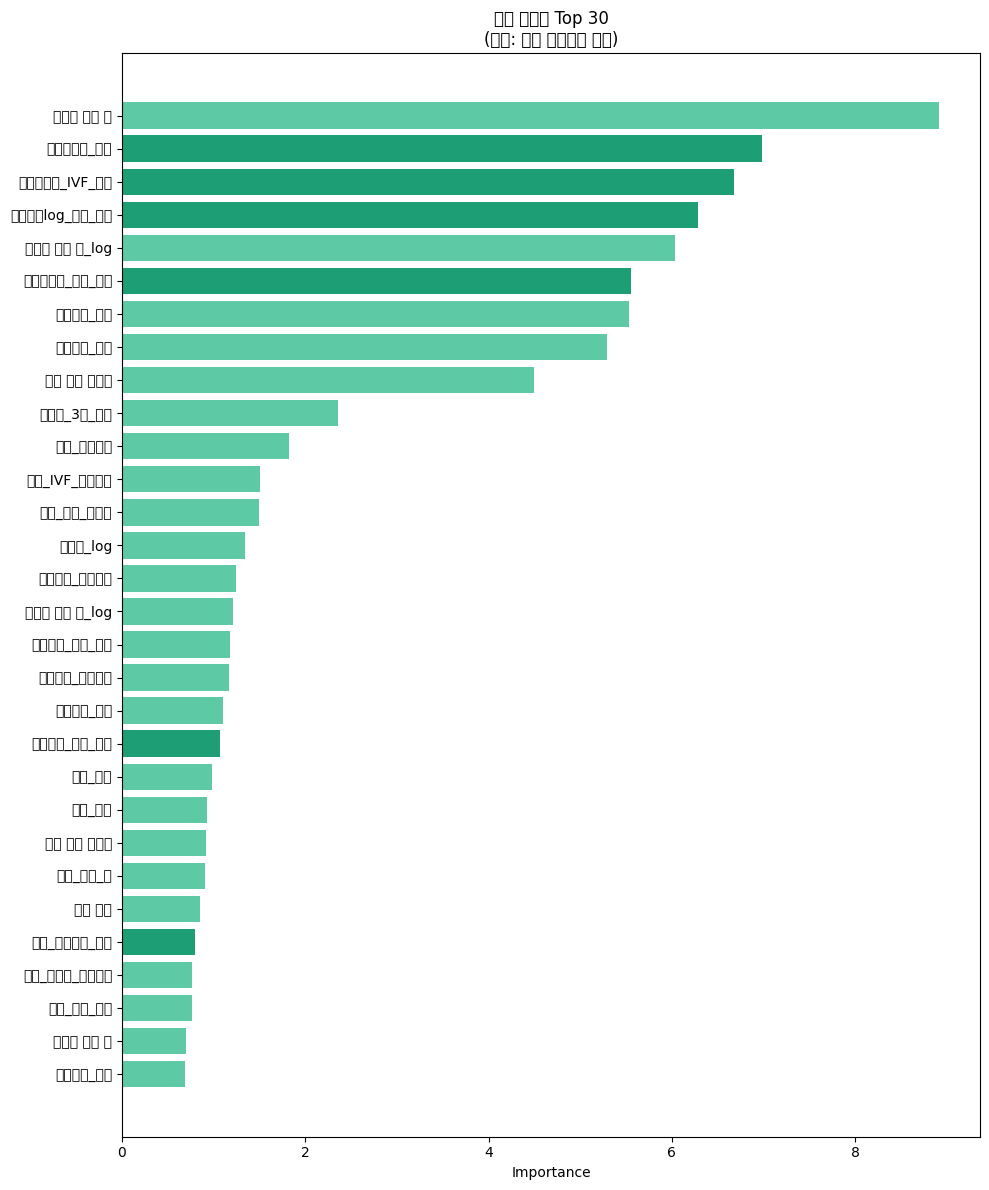


중요도 0 피처 (7개): ['FER_여부', '착상 전 유전 진단 사용 여부_결측여부', '즉시임신단독_여부', '해동배아_있음', 'ICSI_배반포_조합', '배아저장용_포함', '난자혼합_제로_플래그']


In [7]:
# 신규 피처 중요도 확인
import matplotlib.pyplot as plt

importance = np.mean([m.get_feature_importance() for m in models], axis=0)
fi = pd.DataFrame({
    'feature': feat_cols,
    'importance': importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

# 신규 추가 피처만 별도 확인
new_cols = new_interaction_cols + [
    '이식배아수_제곱', '이식배아_총배아_곱',
    '단일배아이식_여부', '2개배아이식_여부'
]
fi_new = fi[fi['feature'].isin(new_cols)].reset_index(drop=True)
print('=== 신규 교호작용 피처 중요도 ===')
display(fi_new)

# Top 30 시각화
fig, ax = plt.subplots(figsize=(10, 12))
top = fi.head(30)
colors = ['#1D9E75' if c in new_cols else '#5DCAA5' for c in top['feature']]
ax.barh(top['feature'][::-1], top['importance'][::-1], color=colors[::-1])
ax.set_title('피처 중요도 Top 30\n(초록: 신규 교호작용 피처)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# 여전히 중요도 0인 피처
zero_imp = fi[fi['importance'] == 0]['feature'].tolist()
print(f'\n중요도 0 피처 ({len(zero_imp)}개): {zero_imp}')

In [8]:
# 제출 파일 저장
sample_path = '/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw/sample_submission.csv'
sample_sub = pd.read_csv(sample_path)

submission = pd.DataFrame({
    sample_sub.columns[0]: test[ID_COL],  # 첫 번째 컬럼명 (예: ID)
    sample_sub.columns[1]: test_preds      # 두 번째 컬럼명 (예: target 또는 probability)
})

submission.to_csv('submission_feature_refinement.csv', index=False, encoding='utf-8-sig')

print(f"제출 파일 컬럼명: {list(submission.columns)}")
print('저장 완료: submission_feature_refinement.csv')

print(f'OOF AUC     : {oof_auc:.5f}')
print(f'베이스라인  : 0.74008')
print(f'개선폭      : {oof_auc - 0.74008:+.5f}')

제출 파일 컬럼명: ['ID', 'probability']
저장 완료: submission_feature_refinement.csv
OOF AUC     : 0.74007
베이스라인  : 0.74008
개선폭      : -0.00001
